C:\Users\Gaurang\AppData\Local\Temp\ipykernel_2788\3847097480.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


Training: units=32, batch=32, lr=0.001
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
 → MSE: 0.000617, R2: -0.2318
Training: units=32, batch=32, lr=0.0005
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step
 → MSE: 0.000584, R2: -0.1666
Training: units=32, batch=32, lr=0.001
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
 → MSE: 0.000582, R2: -0.1632
Training: units=32, batch=32, lr=0.0005
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
 → MSE: 0.000514, R2: -0.0257
Training: units=64, batch=32, lr=0.001
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
 → MSE: 0.000828, R2: -0.6542
Training: units=64, batch=32, lr=0.0005
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
 → MSE: 0.001032, R2: -1.0613
Training: units=64, batch=32, lr=0.001
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
 → MSE: 0.000546, R2: -0.0897
Training: units=64, batch=32, lr=0.0005
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
 → MSE: 0.000657, R2: -0.3127

Best Params: (32, 32, 50, 0.0005)
Best MSE: 0.0005136616826395701
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
GRU Performance:
M

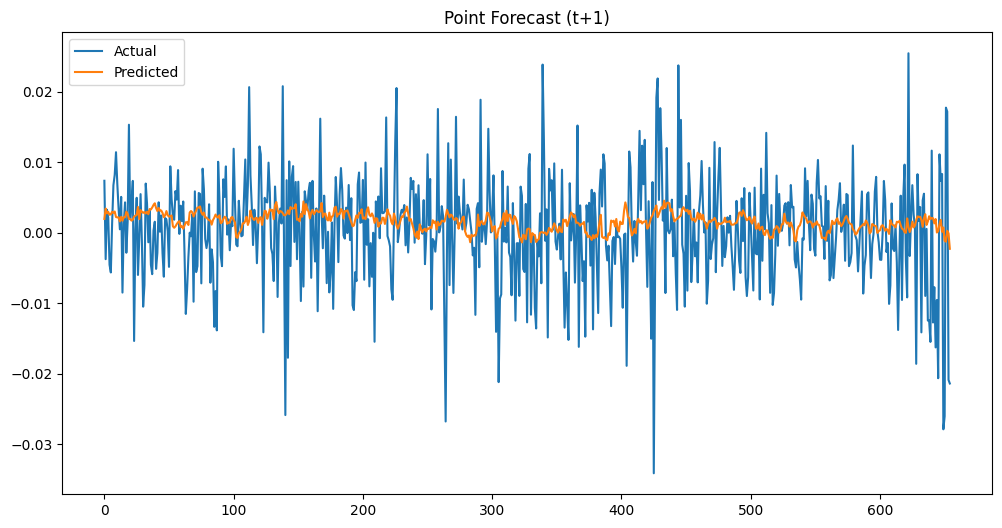

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

df = df[~df.index.duplicated()]
df = df.ffill().bfill()

# Remove outliers
df = df[(np.abs(zscore(df)) < 3).all(axis=1)]

# =========================
# FEATURE ENGINEERING
# =========================

df['return'] = df['close'].pct_change()   # 🔥 point forecasting → 1-step return
df = df.dropna()

for lag in range(1, 6):
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['rolling_mean_5'] = df['return'].rolling(5).mean()
df['rolling_std_5'] = df['return'].rolling(5).std()

df['momentum'] = df['close'] - df['close'].shift(5)

delta = df['close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))

df['EMA_10'] = df['close'].ewm(span=10).mean()
df['volatility'] = df['return'].rolling(10).std()

df['bank_trend'] = df['nifty_bank_ret'].rolling(5).mean()
df['it_trend'] = df['nifty_it_ret'].rolling(5).mean()

df = df.dropna()

# =========================
# DATA PREP
# =========================

features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

# Train-test split BEFORE scaling
split_idx = int(0.8 * len(X))

X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_raw, y_test_raw = y.iloc[:split_idx], y.iloc[split_idx:]

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test_raw.values.reshape(-1,1))

# =========================
# CREATE DATASET (POINT)
# =========================

def create_dataset(X, y, n_steps=20):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps])   # 🔥 only t+1
    return np.array(Xs), np.array(ys)

n_steps = 20

X_train, y_train = create_dataset(X_train_scaled, y_train_scaled, n_steps)
X_test, y_test = create_dataset(X_test_scaled, y_test_scaled, n_steps)

# =========================
# BASELINE (LAST VALUE)
# =========================

y_pred_baseline = y_test.copy()

# =========================
# MODEL
# =========================

def build_attention_gru(n_steps, n_features, units=64, lr=0.001):
    
    inputs = Input(shape=(n_steps, n_features))
    
    x = GRU(units, return_sequences=True)(inputs)
    
    attention = Attention()([x, x])
    
    x = Concatenate()([x, attention])
    
    x = GRU(units)(x)
    
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)   # 🔥 point output
    
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    
    return model

# =========================
# GRID SEARCH
# =========================

param_grid = {
    'units': [32, 64],
    'batch_size': [32],
    'epochs': [30, 50],
    'lr': [0.001, 0.0005]
}

best_score = float('inf')
best_model = None
best_params = None

for units, batch_size, epochs, lr in itertools.product(
    param_grid['units'],
    param_grid['batch_size'],
    param_grid['epochs'],
    param_grid['lr']
):
    
    print(f"Training: units={units}, batch={batch_size}, lr={lr}")
    
    model = build_attention_gru(n_steps, X_train.shape[2], units, lr)
    
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    
    y_pred_temp = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred_temp)
    r2 = r2_score(y_test, y_pred_temp)
    
    print(f" → MSE: {mse:.6f}, R2: {r2:.4f}")
    
    if mse < best_score:
        best_score = mse
        best_model = model
        best_params = (units, batch_size, epochs, lr)

print("\nBest Params:", best_params)
print("Best MSE:", best_score)

# =========================
# PREDICTION
# =========================

y_pred = best_model.predict(X_test)

# reshape
y_test = y_test.reshape(-1,1)
y_pred = y_pred.reshape(-1,1)

# inverse scaling
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_base_inv = scaler_y.inverse_transform(y_pred_baseline)

# =========================
# METRICS
# =========================

def evaluate(y_true, y_pred, name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} Performance:")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*30)

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# =========================
# EVALUATION
# =========================

evaluate(y_test_inv, y_pred_inv, "GRU")
evaluate(y_test_inv, y_base_inv, "Baseline")

print("Directional Accuracy (GRU):", directional_accuracy(y_test_inv, y_pred_inv))
print("Directional Accuracy (Baseline):", directional_accuracy(y_test_inv, y_base_inv))

# =========================
# VISUALIZATION
# =========================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Point Forecast (t+1)")
plt.legend()
plt.show()